In [1]:
"""
Food Delivery Business Performance — Visualization Portfolio

This portfolio uses Matplotlib and Seaborn to explore a food delivery business performance dataset, covering trends over time, comparisons across cities/cuisines/channels, and relationships between marketing spend, delivery time, and customer ratings. Each chart includes a brief interpretation of the insight it reveals, followed by a summary of the most important findings.
"""

'\nFood Delivery Business Performance — Visualization Portfolio\n\nThis portfolio uses Matplotlib and Seaborn to explore a food delivery business performance dataset, covering trends over time, comparisons across cities/cuisines/channels, and relationships between marketing spend, delivery time, and customer ratings. Each chart includes a brief interpretation of the insight it reveals, followed by a summary of the most important findings.\n'

In [2]:
import os;print(os.getcwd())
print(os.listdir())

/Users/mehpreet/CSV DATASETS
['Customers.csv', 'Products.csv', 'studentdataset.csv.rtf', 'Food_Delivery_Business_Performance.csv', '.DS_Store', 'Processed_Ecommerce_Dataset.csv', 'student_performance.csv', 'Untitled.ipynb', 'Order 2017.csv', 'Orders_1.csv', 'Cleaned_Company_Employee_Dataset.csv', 'Restaurant_Branch_Performance.csv', 'Processed_Used_Car_Resale_Dataset.csv', 'Used_Car_Resale_Dataset.csv', 'Flight Operations.csv', '.ipynb_checkpoints', 'messy_employee_dataset.csv', 'Day8_Ecommerce_Sales_Dataset.csv']


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('Food_Delivery_Business_Performance.csv')

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

print("Shape:", df.shape)
df.head()

Shape: (360, 16)


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [4]:
## 1. Line Plot — Monthly Orders and Revenue Trend

## Investigating how order volume and revenue change across the months of the year.

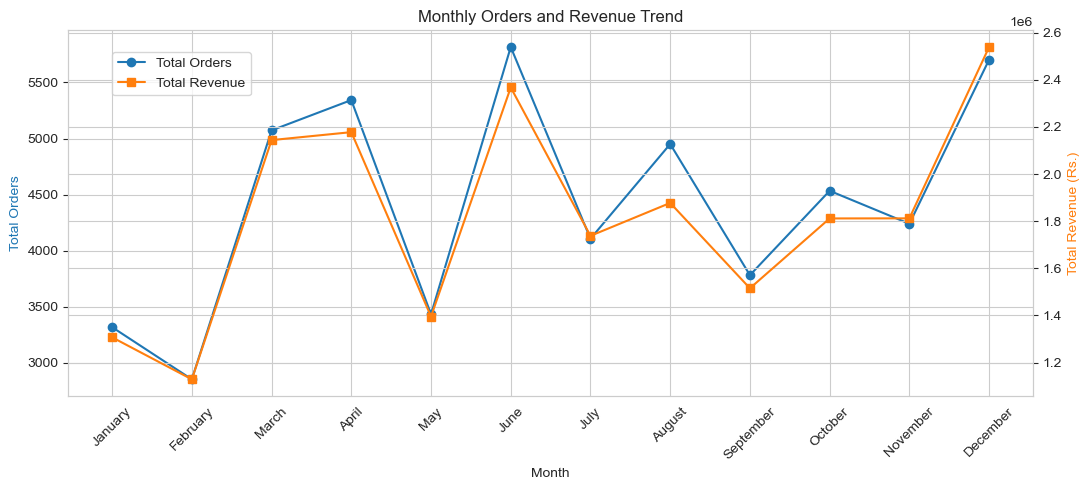

In [52]:
monthly = df.groupby('Month', observed=True).agg(Total_Orders=('Orders', 'sum'), Total_Revenue=('Revenue', 'sum')).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(monthly['Month'], monthly['Total_Orders'], marker='o', color='tab:blue', label='Total Orders')
ax2.plot(monthly['Month'], monthly['Total_Revenue'], marker='s', color='tab:orange', label='Total Revenue')

ax1.set_xlabel('Month')
ax1.set_ylabel('Total Orders', color='tab:blue')
ax2.set_ylabel('Total Revenue (Rs.)', color='tab:orange')
ax1.tick_params(axis='x', rotation=45)
plt.title('Monthly Orders and Revenue Trend')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

In [7]:
## Interpretation: Orders and revenue move together closely throughout the year, confirming revenue is largely volume-driven. June and December stand out as peak months (both over 5,700 orders), while February is the clear low point — worth investigating whether this reflects seasonal demand or fewer operating days.

In [8]:
## 2. Bar Chart — Average Revenue by City

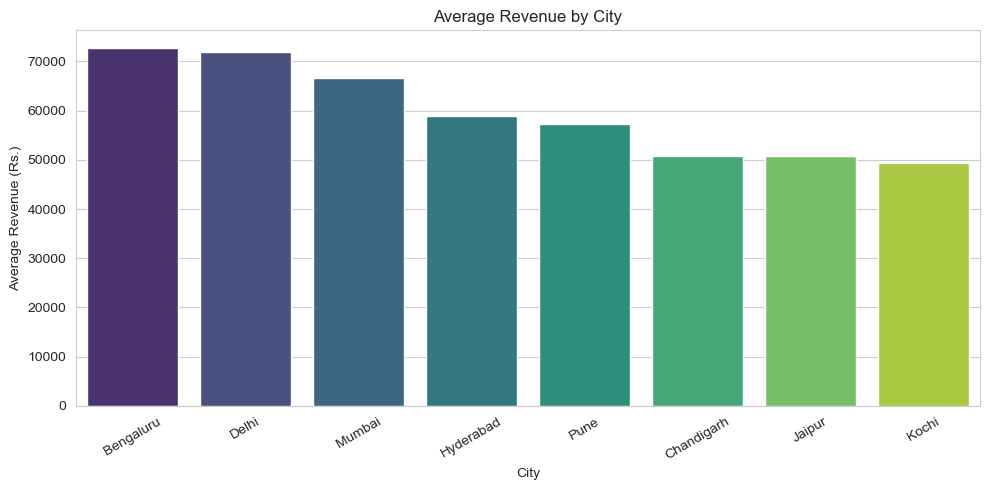

In [53]:
city_revenue = df.groupby('City')['Revenue'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=city_revenue.index, y=city_revenue.values, hue=city_revenue.index, palette='viridis', legend=False)
plt.title('Average Revenue by City')
plt.xlabel('City')
plt.ylabel('Average Revenue (Rs.)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [11]:
## Interpretation: Bengaluru and Delhi lead in average revenue per batch (~₹72,700 and ~₹71,900), while Kochi and Jaipur trail behind (~₹49,500–50,700) — roughly a 32% gap between the top and bottom city, suggesting real differences in local market size or demand density.

In [12]:
## 3. Bar Chart — Average Revenue by Cuisine

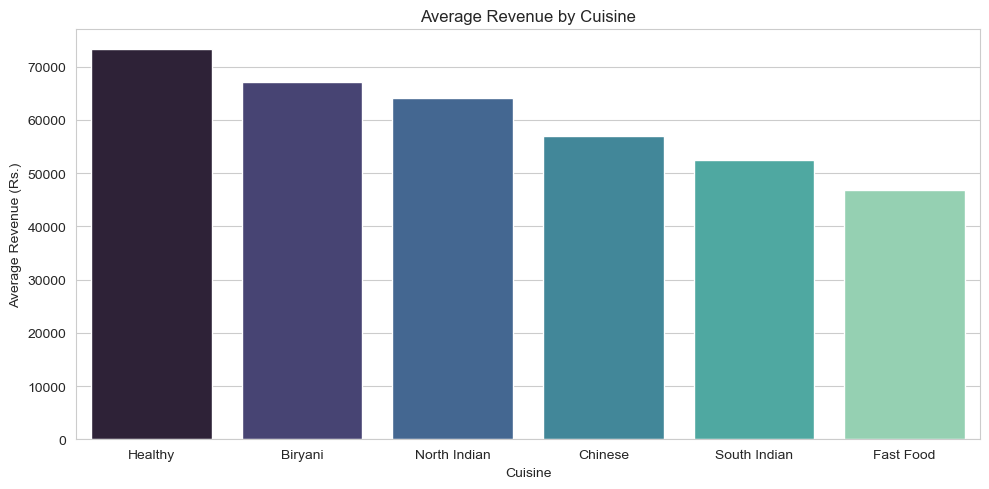

In [54]:
cuisine_revenue = df.groupby('Cuisine')['Revenue'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=cuisine_revenue.index, y=cuisine_revenue.values, hue=cuisine_revenue.index, palette='mako', legend=False)
plt.title('Average Revenue by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Average Revenue (Rs.)')
plt.tight_layout()
plt.show()

In [55]:
## Interpretation: Healthy food generates the highest average revenue (~₹73,400) despite not being the most-ordered cuisine, likely reflecting a higher average order value. Fast Food generates the least (~₹46,800) — consistent with it typically being a lower-ticket, high-volume category.

In [15]:
## 4. Scatter Plot — Marketing Spend vs. Revenue

/var/folders/mz/cxv66sf95tv5plj6b4q0mb2w0000gn/T/ipykernel_9397/1833613252.py:7: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


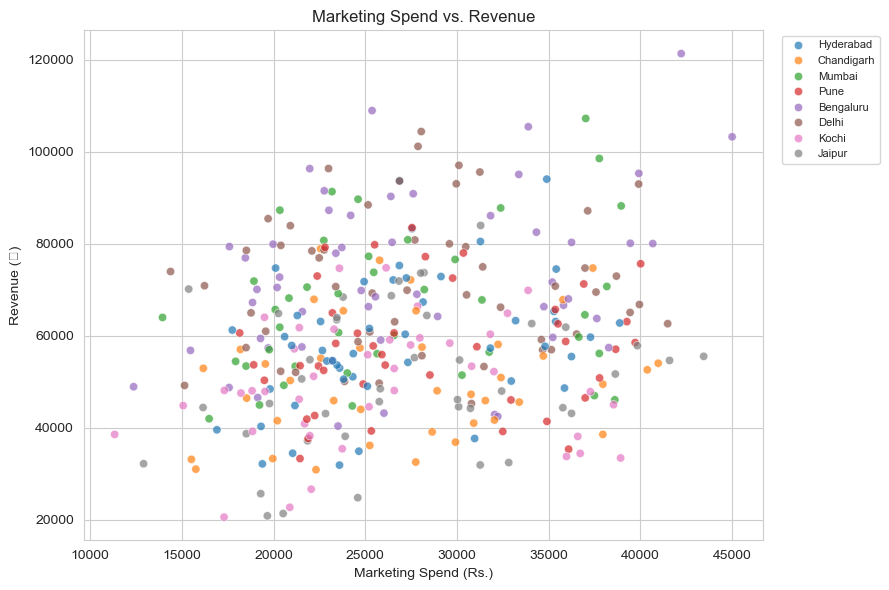

Correlation (Marketing Spend, Revenue): 0.198


In [56]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Marketing_Spend', y='Revenue', hue='City', alpha=0.7)
plt.title('Marketing Spend vs. Revenue')
plt.xlabel('Marketing Spend (Rs.)')
plt.ylabel('Revenue (₹)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print("Correlation (Marketing Spend, Revenue):", df['Marketing_Spend'].corr(df['Revenue']).round(3))

In [57]:
## Interpretation: The relationship is only weakly positive (r ≈ 0.20) and the scatter is wide — many high-marketing-spend batches don't generate proportionally higher revenue. Marketing spend alone is a poor predictor of revenue in this dataset.

In [18]:
## 5. Scatter Plot — Delivery Time vs. Customer Rating

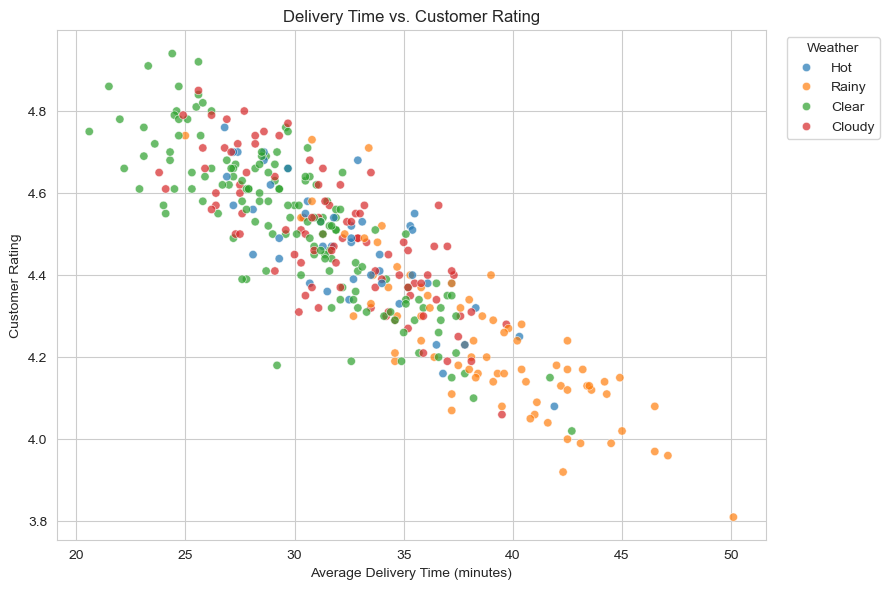

Correlation (Delivery Time, Rating): -0.876


In [19]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Avg_Delivery_Minutes', y='Customer_Rating', hue='Weather', alpha=0.7)
plt.title('Delivery Time vs. Customer Rating')
plt.xlabel('Average Delivery Time (minutes)')
plt.ylabel('Customer Rating')
plt.legend(title='Weather', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Correlation (Delivery Time, Rating):", df['Avg_Delivery_Minutes'].corr(df['Customer_Rating']).round(3))

In [21]:
## Interpretation: This is the strongest relationship in the entire dataset (r ≈ -0.88) — as delivery time increases, customer rating drops sharply and consistently. Delivery speed is clearly the dominant factor behind customer satisfaction, far more than any other variable measured.

In [22]:
## 6. Histograms — Distribution of Key Numeric Variables

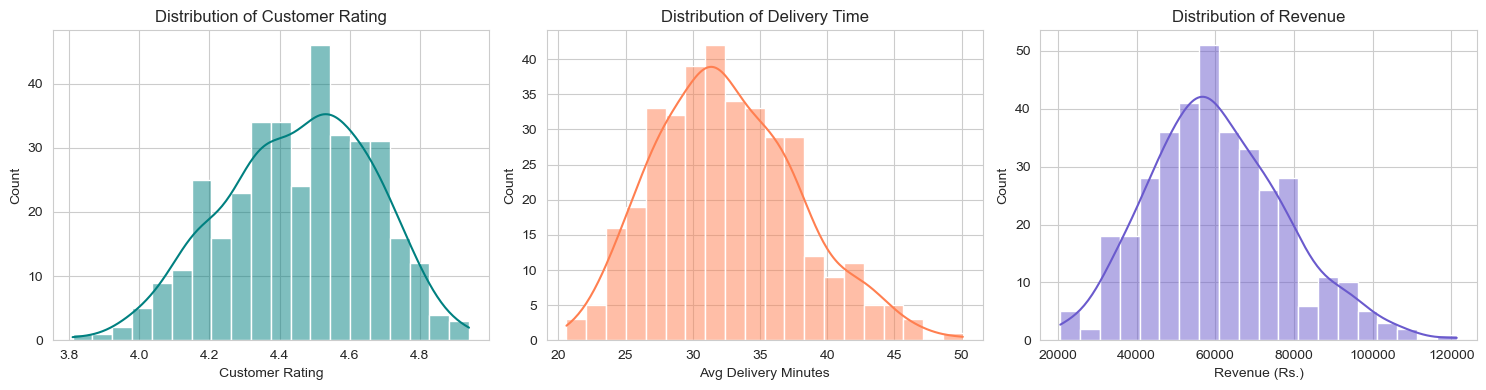

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Customer_Rating'], bins=20, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Customer Rating')
axes[0].set_xlabel('Customer Rating')

sns.histplot(df['Avg_Delivery_Minutes'], bins=20, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Delivery Time')
axes[1].set_xlabel('Avg Delivery Minutes')

sns.histplot(df['Revenue'], bins=20, kde=True, ax=axes[2], color='slateblue')
axes[2].set_title('Distribution of Revenue')
axes[2].set_xlabel('Revenue (Rs.)')

plt.tight_layout()
plt.show()

In [25]:
## Interpretation: Customer ratings cluster tightly between 4.0–4.9, showing generally strong satisfaction with few very poor experiences. Delivery time is right-skewed with a long tail past 40 minutes — these tail cases likely correspond to the lowest-rated batches seen in the scatter plot above. Revenue is fairly evenly spread with a mild right skew, driven by a handful of especially large batches.

In [26]:
## 7. Box Plot — Delivery Time by Weather

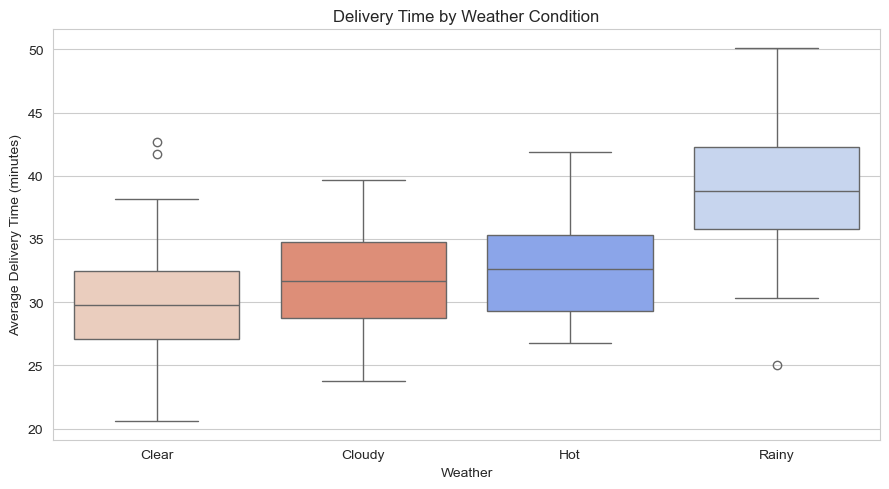

In [27]:
plt.figure(figsize=(9, 5))
weather_order = df.groupby('Weather')['Avg_Delivery_Minutes'].median().sort_values().index
sns.boxplot(data=df, x='Weather', y='Avg_Delivery_Minutes', hue='Weather', order=weather_order, palette='coolwarm', legend=False)
plt.title('Delivery Time by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Average Delivery Time (minutes)')
plt.tight_layout()
plt.show()

In [29]:
## Interpretation: Rainy weather clearly pushes delivery times higher (median well above the other conditions) and shows the widest spread — meaning rain doesn't just slow deliveries on average, it also makes delivery times far less predictable.

In [30]:
## 8. Box Plot — Revenue by Order Channel

/var/folders/mz/cxv66sf95tv5plj6b4q0mb2w0000gn/T/ipykernel_9397/2895186144.py:6: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


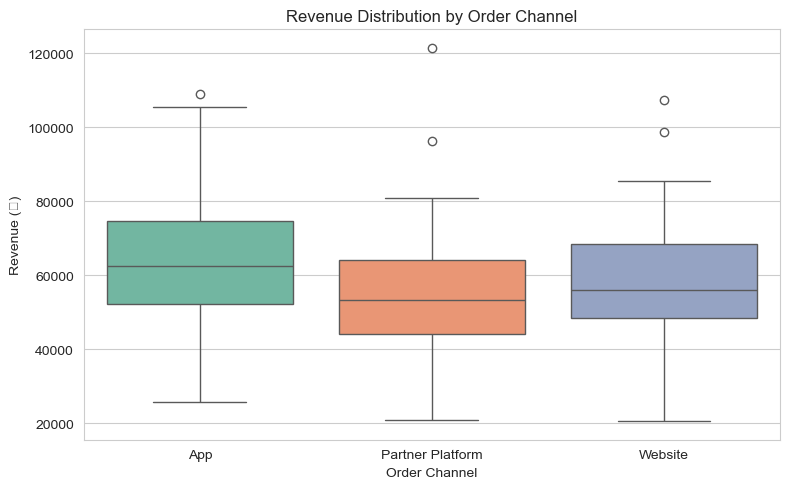

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Order_Channel', y='Revenue', hue='Order_Channel', palette='Set2', legend=False)
plt.title('Revenue Distribution by Order Channel')
plt.xlabel('Order Channel')
plt.ylabel('Revenue (R)')
plt.tight_layout()
plt.show()

In [33]:
## Interpretation: The App channel shows both a higher median revenue and a wider upper range than Website or Partner Platform, suggesting the app drives the highest-value order batches, not just the most orders.

In [34]:
## 9. Violin Plot — Customer Rating by Cuisine

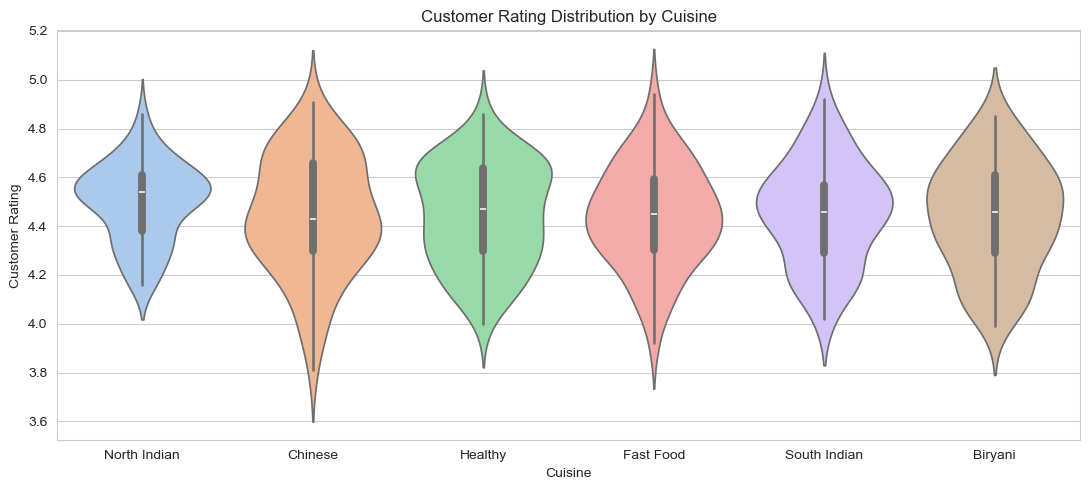

In [35]:
plt.figure(figsize=(11, 5))
sns.violinplot(data=df, x='Cuisine', y='Customer_Rating', hue='Cuisine', palette='pastel', legend=False)
plt.title('Customer Rating Distribution by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Customer Rating')
plt.tight_layout()
plt.show()

In [37]:
## Interpretation: Rating distributions are broadly similar and overlapping across cuisines, with no cuisine standing out as a clear satisfaction leader or laggard — reinforcing that operational factors like delivery time matter far more to rating than what's being ordered.

In [38]:
## 10. Count Plots — Order Channel and Weather Frequency

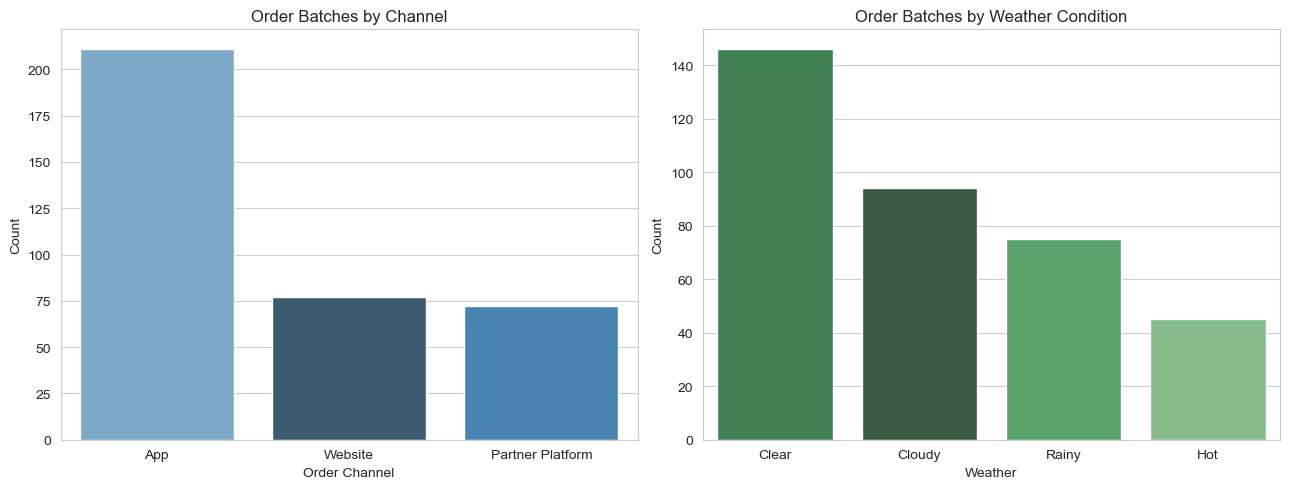

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='Order_Channel', hue='Order_Channel', palette='Blues_d', legend=False,
              order=df['Order_Channel'].value_counts().index, ax=axes[0])
axes[0].set_title('Order Batches by Channel')
axes[0].set_xlabel('Order Channel')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='Weather', hue='Weather', palette='Greens_d', legend=False,
              order=df['Weather'].value_counts().index, ax=axes[1])
axes[1].set_title('Order Batches by Weather Condition')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [41]:
## Interpretation: The App is the dominant order channel (211 of 360 batches, ~59%), far ahead of Website and Partner Platform combined. Most batches occur in Clear or Cloudy weather, with Rainy conditions being comparatively rare — meaning the rain-driven delivery delays seen earlier, while impactful, affect a smaller share of overall operations.

In [42]:
## 11. Correlation Heatmap

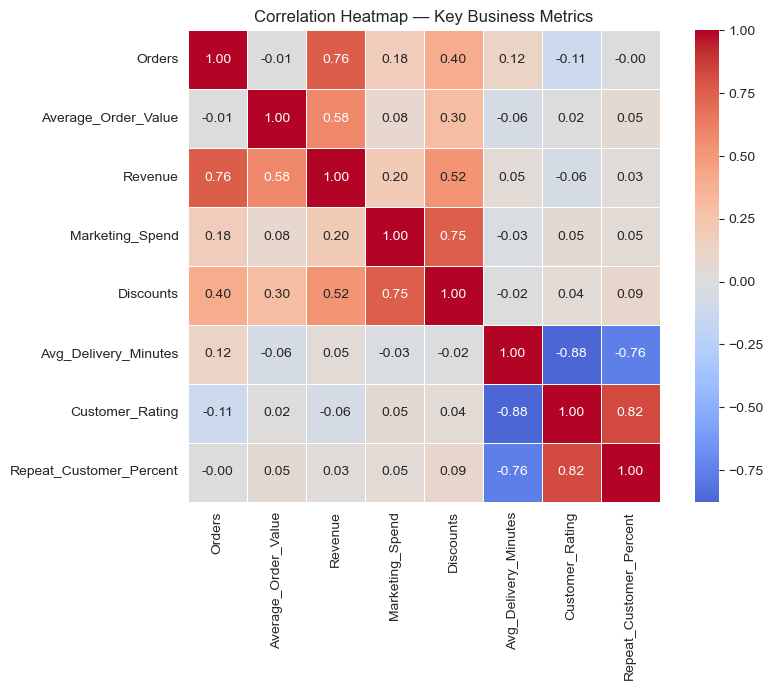

In [43]:
numeric_cols = ['Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts',
                'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

plt.figure(figsize=(9, 7))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Key Business Metrics')
plt.tight_layout()
plt.show()

In [45]:
## Interpretation: Two relationships dominate the matrix: Avg_Delivery_Minutes vs. Customer_Rating (-0.88) and Customer_Rating vs. Repeat_Customer_Percent (0.82). Together they trace a clear operational chain — delivery speed drives rating, and rating drives repeat business — while Marketing_Spend correlates weakly with everything, including Revenue (0.20).

In [48]:
## Key Business Insights

## 1. Delivery speed is the single biggest lever on customer satisfaction and loyalty. The correlation between delivery time and rating (-0.88) is by far the strongest relationship in the dataset, and rating in turn strongly predicts repeat customer percentage (0.82).
## 2. Marketing spend is a weak predictor of revenue (r ≈ 0.20). Revenue is driven far more by order volume (r ≈ 0.76) and average order value (r ≈ 0.58).
## 3. Rainy weather is an operational stress point — highest average delivery time (38.75 min vs. 29.99 min in clear weather) and lowest average rating (4.23 vs. 4.53).
## 4. City and cuisine performance vary substantially — average revenue per batch ranges from ~₹49,500 (Kochi) to ~₹72,700 (Bengaluru), and from ~₹46,800 (Fast Food) to ~₹73,400 (Healthy).
## 5. The App channel outperforms other channels on both volume and revenue, accounting for 59% of order batches with the highest median and upper-range revenue.

In [49]:
## Recommendations for Management

## 1. Prioritize delivery speed improvements above all other satisfaction levers.
## 2. Build a weather-responsive operations plan for rainy days.
## 3. Reassess marketing spend allocation, since spend only weakly correlates with revenue.
## 4. Invest further in the App channel, since it already leads in both volume and revenue.
## 5. Investigate the underperforming cities (Kochi, Jaipur) and cuisines (Fast Food, South Indian).
## 6. Treat customer rating as a leading indicator for retention risk, not just a satisfaction score.
## 7. Investigate the February dip in orders and revenue to determine if it's seasonal or a one-off issue.